# Importin Packages

In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

Deep modules

In [215]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# Loading Dataset

In [216]:
df = pd.read_csv('dataset/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [217]:
df.shape

(20640, 10)

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [219]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [220]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [221]:
df.dropna(inplace=True)

In [222]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# Encoding

In [223]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [224]:
mapping = {
    '<1H OCEAN': 0,
    'INLAND': 1,
    'NEAR OCEAN': 2,
    'NEAR BAY': 3,
    'ISLAND': 4
}

df['ocean_proximity'] = df['ocean_proximity'].map(mapping)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1


# Train Test Split

In [225]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [226]:
X = np.array(X)
y = np.array(y)

In [227]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [228]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16346, 9)
(4087, 9)
(16346,)
(4087,)


# Scaling

In [229]:
min_max_scaler = MinMaxScaler()
X_train = min_max_scaler.fit_transform(X_train)
X_test = min_max_scaler.fit_transform(X_test)


In [230]:
X_train

array([[0.25809717, 0.50797024, 0.25490196, ..., 0.14635751, 0.28984428,
        0.        ],
       [0.47773279, 0.4357067 , 0.62745098, ..., 0.02844927, 0.20074206,
        0.25      ],
       [0.63663968, 0.16790648, 0.47058824, ..., 0.12465055, 0.21820389,
        0.25      ],
       ...,
       [0.60020243, 0.15621679, 0.80392157, ..., 0.05936524, 0.1792458 ,
        0.        ],
       [0.23380567, 0.53453773, 0.21568627, ..., 0.17365565, 0.33020234,
        0.75      ],
       [0.19433198, 0.55154091, 1.        , ..., 0.10623253, 0.23403125,
        0.75      ]], shape=(16346, 9))

# Model train annd Architecture

In [231]:
model = Sequential([
    #input layer
    Dense(1000, input_shape=[X_train.shape[1], ], activation='relu'),
    #hidden layer1
    Dense(500, activation='relu'),
    #hidden layer2
    Dense(250, activation='relu'),
    #output layer
    Dense(1, activation='linear')
])
model.summary()

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 1000)           │        10,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 636,001 (2.43 MB)

 Trainable params: 636,001 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [232]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss', mode='min', patience=50, restore_best_weights=True)

In [233]:
history = model.fit(X_train, y_train, validation_data= (X_test, y_test), callbacks=[es], epochs=10, batch_size=50, verbose=1)

Epoch 1/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26317864960.0000 - mae: 124958.9453 - val_loss: 11589228544.0000 - val_mae: 87203.2031
Epoch 2/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9646022656.0000 - mae: 77846.6641 - val_loss: 8066000384.0000 - val_mae: 71059.1016
Epoch 3/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6510728192.0000 - mae: 61407.4336 - val_loss: 6073660928.0000 - val_mae: 56498.4062
Epoch 4/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5812566528.0000 - mae: 56086.9219 - val_loss: 5871183360.0000 - val_mae: 54938.9531
Epoch 5/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5639724544.0000 - mae: 55021.0625 - val_loss: 5694133248.0000 - val_mae: 53939.2891
Epoch 6/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5467364352.0000 - mae: 53920.8711 - val_loss: 5678517760.0000 - val_mae: 53179.9453
Epoch 7/10
327/327 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5299391488.0000 - mae: 52893.3359 - val_loss: 5956403712.0000 - val_mae: 

# Model Results and Metrics

In [234]:
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_log_error, mean_absolute_error
y_pred = model.predict(X_test)
print('mae :', mean_absolute_error(y_test, y_pred))
print('mse :', mean_squared_error(y_test, y_pred))
print('mae :', mean_squared_log_error(y_test, y_pred))
print('mae :', r2_score(y_test, y_pred))

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
mae : 52698.49264291624
mse : 5485814158.233874
mae : 0.1638220330615884
mae : 0.5988488749025932


In [235]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss) + 1)

Plot the training and validation lost

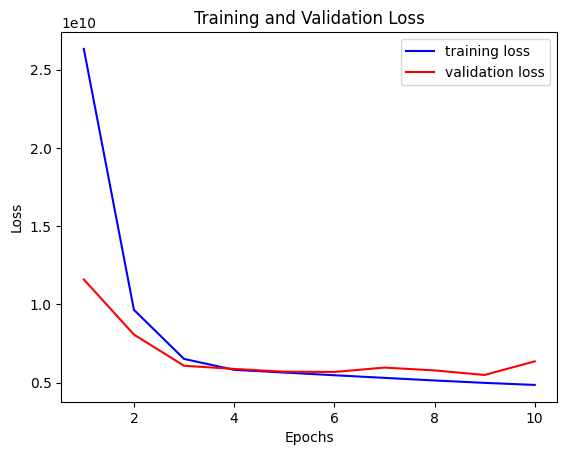

In [236]:
plt.plot(epochs, training_loss, 'b', label='training loss')
plt.plot(epochs, validation_loss, 'r', label='validation loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot training and validation results

511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step


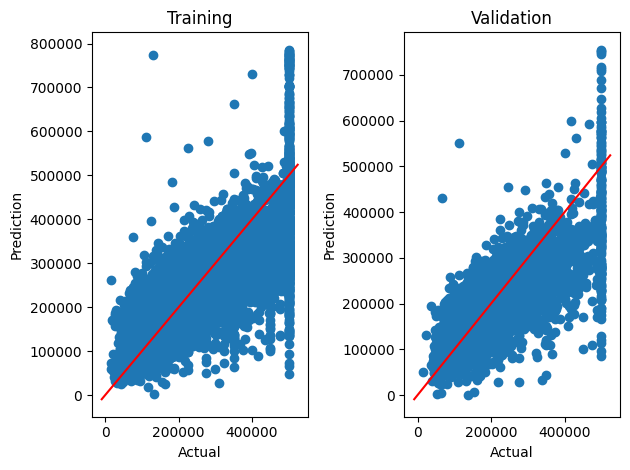

In [237]:
fig, axes = plt.subplots(1, 2)

#Training
axes[0].scatter(x=y_train, y=model.predict(X_train))
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Prediction')
axes[0].set_title('Training')
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')

#Validation
axes[1].scatter(x=y_test, y=model.predict(X_test))
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Prediction')
axes[1].set_title('Validation')
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

fig.tight_layout()
plt.show()

# Predictive System

In [238]:
def pred(longitude, 
         latitude ,       
         housing_median_age,
         total_rooms,
         total_bedrooms,
         population,
         households,
         median_income,
         ocean_proximity
        ):
    features = np.array([longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, ocean_proximity])
    features_scaled = min_max_scaler.fit_transform([features])
    result = model.predict(features_scaled).reshape(1, -1)
    return result[0]

In [239]:
df.iloc[0]

longitude               -122.2300
latitude                  37.8800
housing_median_age        41.0000
total_rooms              880.0000
total_bedrooms           129.0000
population               322.0000
households               126.0000
median_income              8.3252
median_house_value    452600.0000
ocean_proximity            3.0000
Name: 0, dtype: float64

In [240]:
longitude = -122.2300
latitude  = 37.8800
housing_median_age  = 41.0000
total_rooms        = 880.0000
total_bedrooms   =  129.0000
population     = 322.0000
households          =    126.0000
median_income       =      8.3252
ocean_proximity       =     3.0000

price = pred(longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [241]:
price

array([231626.7], dtype=float32)

# Save Model

In [243]:
model.save('model.h5')
import pickle
pickle.dump(min_max_scaler, open('min_max_scaler.pkl', 'wb'))